In [1]:
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import resample

from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
zip_path = "input.zip"
extract_path = "./"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped input.zip to ./input")

Unzipped input.zip to ./input


In [3]:
def plot_two_participants_standing_with_windows(
    person_ids=(1, 2),
    base_path="./input",
    fs=52,
    standing_label=3,
    seconds_to_plot=60,
    window_seconds=10,
):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

    for ax, person_id in zip(axes, person_ids):
        file_path = os.path.join(base_path, f"{person_id}.csv")

        df = pd.read_csv(
            file_path,
            names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
        )

        df = df[df["Labels"] == standing_label].copy().reset_index(drop=True)

        n = min(len(df), int(seconds_to_plot * fs))
        df = df.iloc[:n].copy()

        t = np.arange(len(df)) / fs

        x = df["x_acceleration"].astype(float).to_numpy()
        y = df["y_acceleration"].astype(float).to_numpy()
        z = df["z_acceleration"].astype(float).to_numpy()
        mag = np.sqrt(x**2 + y**2 + z**2)

        ax.plot(t, x, label="x", alpha=0.7)
        ax.plot(t, y, label="y", alpha=0.7)
        ax.plot(t, z, label="z", alpha=0.7)
        ax.plot(t, mag, label="magnitude", linewidth=2)

        # show 10-second windows
        for start_sec in np.arange(0, t[-1], window_seconds):
            end_sec = start_sec + window_seconds
            ax.axvspan(start_sec, end_sec, alpha=0.08)

        # vertical lines at window boundaries
        for boundary in np.arange(0, t[-1] + window_seconds, window_seconds):
            ax.axvline(boundary, linestyle=":", alpha=0.5)

        ax.set_title(f"Person {person_id}: Standing signal, label={standing_label}")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Raw acceleration units")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


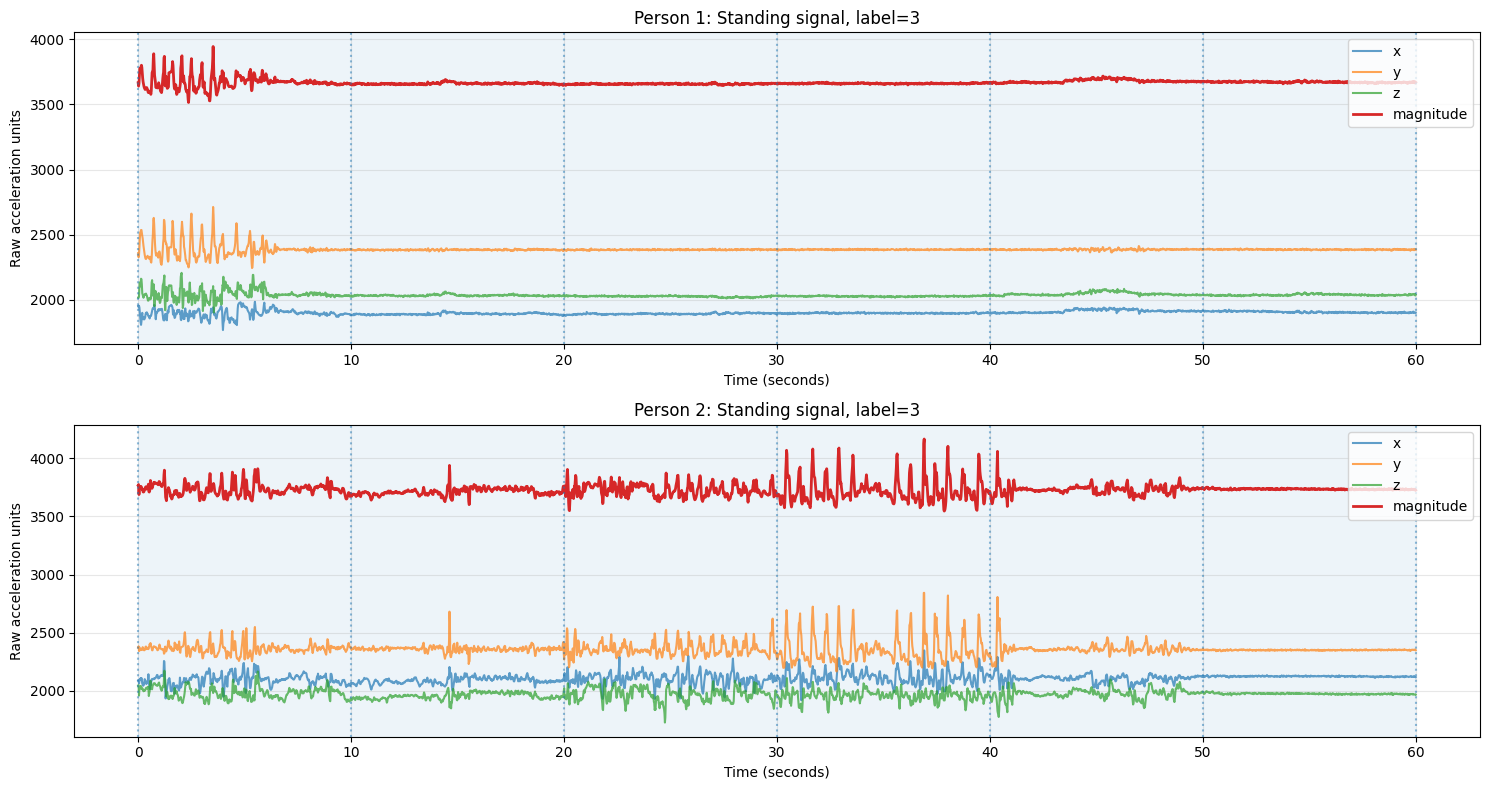

In [4]:

plot_two_participants_standing_with_windows(
    person_ids=(1, 2),
    base_path="./input",
    fs=52,
    standing_label=3,
    seconds_to_plot=60,
    window_seconds=10,
)

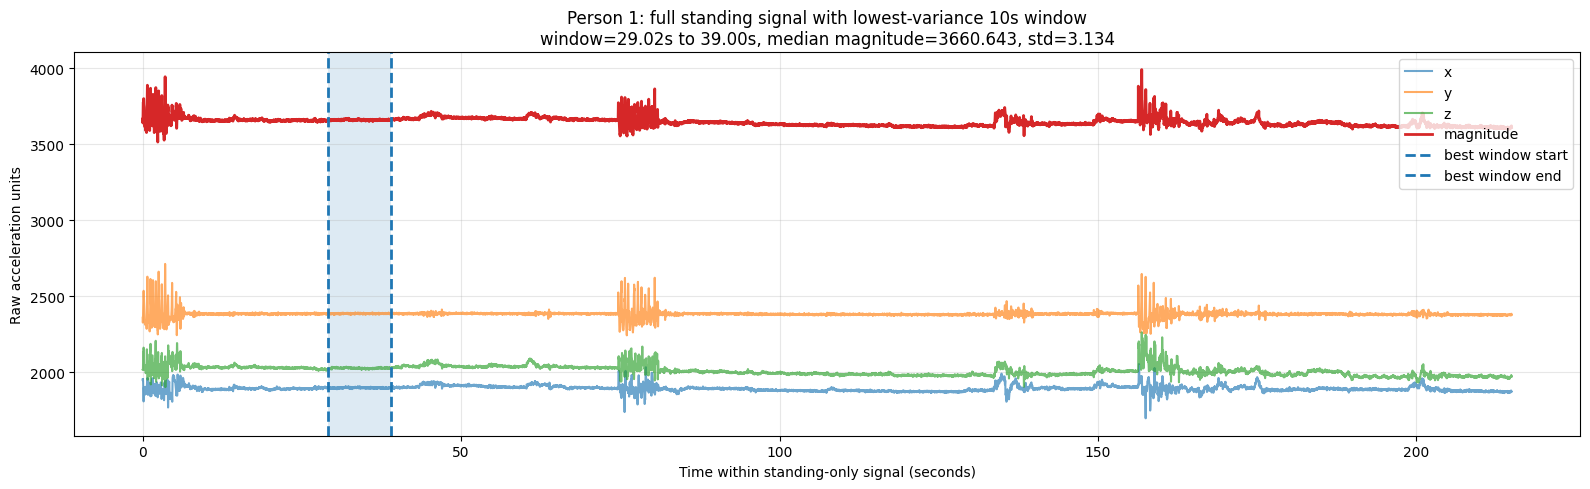

In [5]:
def plot_standing_signal_with_best_static_window(
    person_id,
    base_path="./input",
    fs=52,
    standing_label=3,
    window_seconds=10
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    file_path = os.path.join(base_path, f"{person_id}.csv")

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    df = df[df["Labels"] == standing_label].copy().reset_index(drop=True)

    xyz = df[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float).to_numpy()
    mag = np.sqrt(np.sum(xyz**2, axis=1))

    window_size = int(window_seconds * fs)

    if len(df) < window_size:
        print(f"Person {person_id} does not have enough standing data.")
        return None

    rolling_std = pd.Series(mag).rolling(
        window=window_size,
        center=False,
        min_periods=window_size
    ).std()

    end_idx = rolling_std.idxmin()
    start_idx = end_idx - window_size + 1

    t = np.arange(len(df)) / fs
    start_sec = start_idx / fs
    end_sec = end_idx / fs

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    plt.figure(figsize=(16, 5))

    plt.plot(t, x, label="x", alpha=0.65)
    plt.plot(t, y, label="y", alpha=0.65)
    plt.plot(t, z, label="z", alpha=0.65)
    plt.plot(t, mag, label="magnitude", linewidth=2)

    plt.axvline(start_sec, linestyle="--", linewidth=2, label="best window start")
    plt.axvline(end_sec, linestyle="--", linewidth=2, label="best window end")
    plt.axvspan(start_sec, end_sec, alpha=0.15)

    plt.title(
        f"Person {person_id}: full standing signal with lowest-variance "
        f"{window_seconds}s window\n"
        f"window={start_sec:.2f}s to {end_sec:.2f}s, "
        f"median magnitude={np.median(mag[start_idx:end_idx + 1]):.3f}, "
        f"std={np.std(mag[start_idx:end_idx + 1]):.3f}"
    )

    plt.xlabel("Time within standing-only signal (seconds)")
    plt.ylabel("Raw acceleration units")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    return {
        "person_id": person_id,
        "start_idx": start_idx,
        "end_idx": end_idx,
        "start_sec": start_sec,
        "end_sec": end_sec,
        "counts_per_g_estimate": np.median(mag[start_idx:end_idx + 1]),
        "magnitude_std": np.std(mag[start_idx:end_idx + 1]),
    }


out = plot_standing_signal_with_best_static_window(
    person_id=1,
    base_path="./input",
    fs=52,
    standing_label=3,
    window_seconds=10
)

In [6]:
# from the previous function output
counts_per_g = out["counts_per_g_estimate"]

print("Using counts_per_g:", counts_per_g)

Using counts_per_g: 3660.6434543666073


In [7]:
def load_person_converted_to_g(
    person_id,
    counts_per_g,
    base_path="./input",
    drop_label_0=True
):
    file_path = os.path.join(base_path, f"{person_id}.csv")

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    df = df.reset_index(drop=True)

    accel_cols = ["x_acceleration", "y_acceleration", "z_acceleration"]

    df[accel_cols] = df[accel_cols].astype(float) / counts_per_g

    return df

In [8]:
df_g = load_person_converted_to_g(
    person_id=1,
    counts_per_g=counts_per_g,
    base_path="./input"
)

x = df_g["x_acceleration"].to_numpy()
y = df_g["y_acceleration"].to_numpy()
z = df_g["z_acceleration"].to_numpy()

mag_g = np.sqrt(x**2 + y**2 + z**2)

print("Converted magnitude median:", np.median(mag_g))
print("Converted magnitude mean:", np.mean(mag_g))
print("Converted magnitude std:", np.std(mag_g))

Converted magnitude median: 0.99806670205342
Converted magnitude mean: 1.003234147138892
Converted magnitude std: 0.014479063179045433


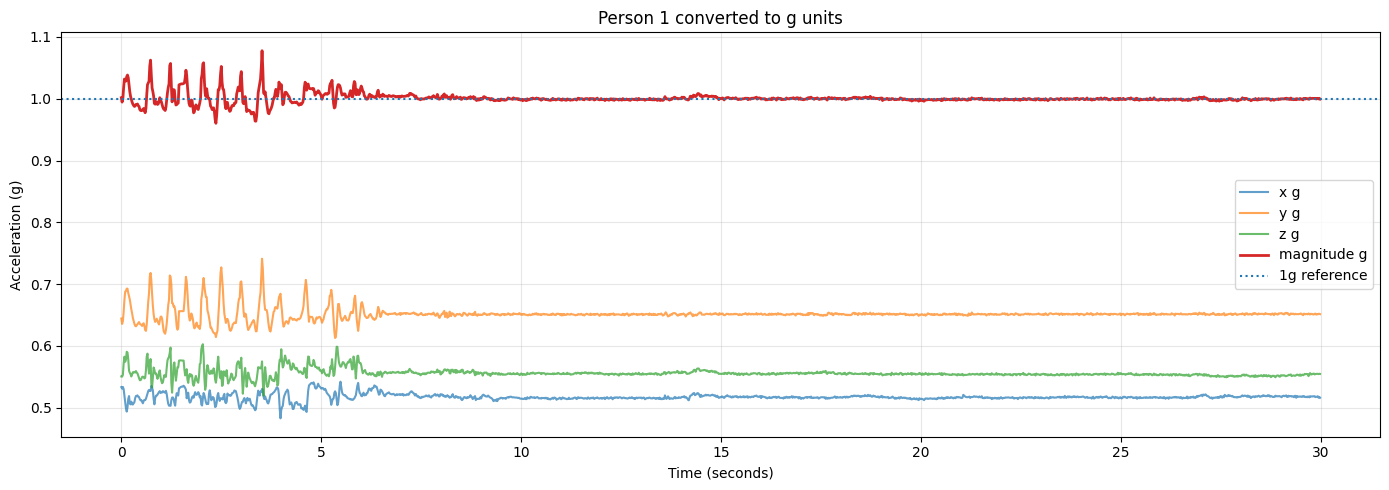

In [9]:
def plot_converted_signal_g(
    person_id,
    counts_per_g,
    base_path="./input",
    label=None,
    fs=52,
    seconds_to_plot=30
):
    df = load_person_converted_to_g(
        person_id=person_id,
        counts_per_g=counts_per_g,
        base_path=base_path
    )

    if label is not None:
        df = df[df["Labels"] == label].copy().reset_index(drop=True)

    n = min(len(df), int(seconds_to_plot * fs))
    df = df.iloc[:n]

    x = df["x_acceleration"].to_numpy()
    y = df["y_acceleration"].to_numpy()
    z = df["z_acceleration"].to_numpy()
    mag = np.sqrt(x**2 + y**2 + z**2)

    t = np.arange(len(df)) / fs

    plt.figure(figsize=(14, 5))
    plt.plot(t, x, label="x g", alpha=0.7)
    plt.plot(t, y, label="y g", alpha=0.7)
    plt.plot(t, z, label="z g", alpha=0.7)
    plt.plot(t, mag, label="magnitude g", linewidth=2)

    plt.axhline(1.0, linestyle=":", label="1g reference")

    plt.title(f"Person {person_id} converted to g units")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration (g)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_converted_signal_g(
    person_id=1,
    counts_per_g=counts_per_g,
    base_path="./input",
    label=3,
    fs=52,
    seconds_to_plot=30
)

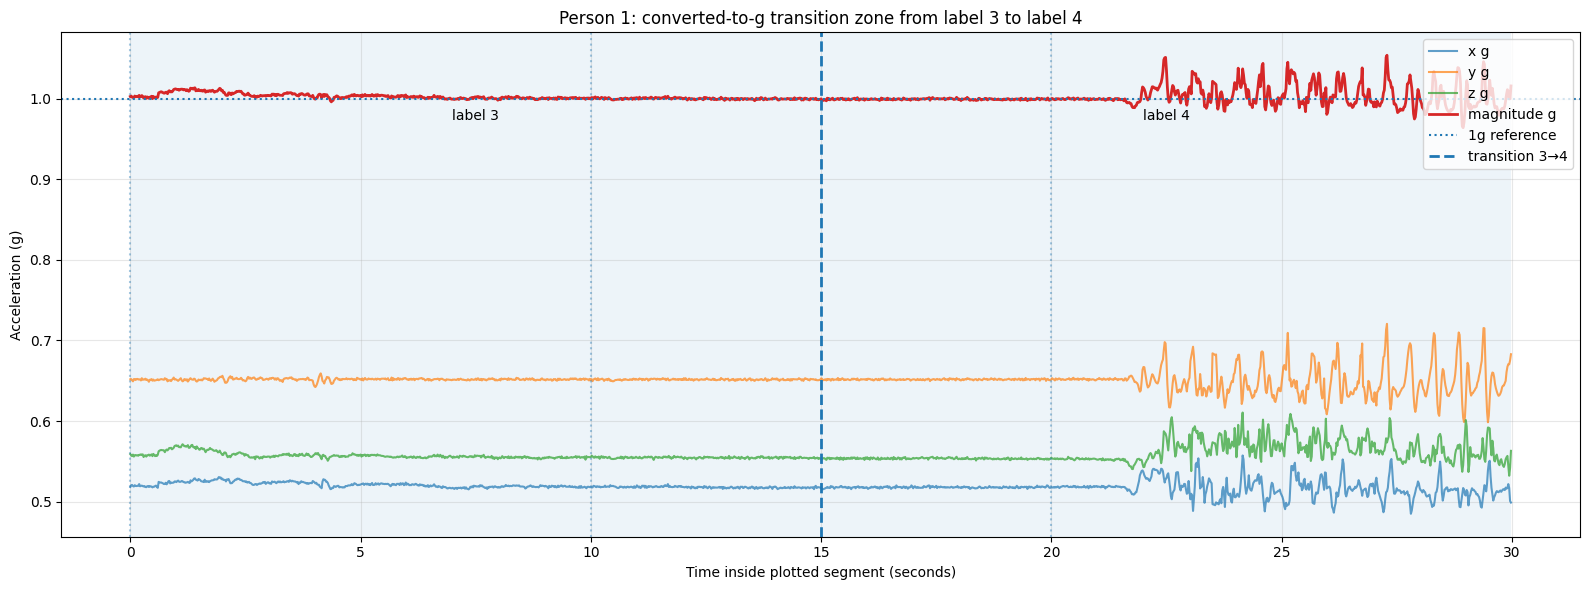

In [10]:
def plot_transition_zone_converted_g(
    person_id,
    counts_per_g,
    from_label=3,   # standing
    to_label=4,     # walking
    base_path="./input",
    fs=52,
    context_seconds=20,
    window_seconds=10
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    file_path = os.path.join(base_path, f"{person_id}.csv")

    df = pd.read_csv(
        file_path,
        names=["Sequence", "x_acceleration", "y_acceleration", "z_acceleration", "Labels"]
    )

    accel_cols = ["x_acceleration", "y_acceleration", "z_acceleration"]
    df[accel_cols] = df[accel_cols].astype(float) / counts_per_g

    labels = df["Labels"].to_numpy()

    # Find first direct transition from from_label to to_label
    transition_idx = None
    for i in range(1, len(labels)):
        if labels[i - 1] == from_label and labels[i] == to_label:
            transition_idx = i
            break

    if transition_idx is None:
        print(f"No direct transition found from label {from_label} to label {to_label}.")
        return None

    half_context = int((context_seconds * fs) // 2)
    start = max(0, transition_idx - half_context)
    end = min(len(df), transition_idx + half_context)

    seg = df.iloc[start:end].copy().reset_index(drop=True)

    x = seg["x_acceleration"].to_numpy()
    y = seg["y_acceleration"].to_numpy()
    z = seg["z_acceleration"].to_numpy()
    mag = np.sqrt(x**2 + y**2 + z**2)
    lab = seg["Labels"].to_numpy()

    t = np.arange(len(seg)) / fs
    transition_time = (transition_idx - start) / fs

    plt.figure(figsize=(16, 6))

    plt.plot(t, x, label="x g", alpha=0.7)
    plt.plot(t, y, label="y g", alpha=0.7)
    plt.plot(t, z, label="z g", alpha=0.7)
    plt.plot(t, mag, label="magnitude g", linewidth=2)

    plt.axhline(1.0, linestyle=":", label="1g reference")
    plt.axvline(transition_time, linestyle="--", linewidth=2, label=f"transition {from_label}→{to_label}")

    # show 10s windows
    for w_start in np.arange(0, t[-1], window_seconds):
        w_end = w_start + window_seconds
        plt.axvspan(w_start, min(w_end, t[-1]), alpha=0.08)
        plt.axvline(w_start, linestyle=":", alpha=0.4)

    # label background by activity
    change_points = np.where(lab[1:] != lab[:-1])[0] + 1
    boundaries = np.r_[0, change_points, len(lab)]

    for a, b in zip(boundaries[:-1], boundaries[1:]):
        mid = (a + b) // 2
        plt.text(
            t[mid],
            plt.ylim()[1] * 0.9,
            f"label {lab[mid]}",
            ha="center",
            fontsize=10
        )

    plt.title(
        f"Person {person_id}: converted-to-g transition zone "
        f"from label {from_label} to label {to_label}"
    )
    plt.xlabel("Time inside plotted segment (seconds)")
    plt.ylabel("Acceleration (g)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    return {
        "person_id": person_id,
        "transition_idx_global": transition_idx,
        "segment_start_global": start,
        "segment_end_global": end,
        "transition_time_local_seconds": transition_time,
    }


out_transition = plot_transition_zone_converted_g(
    person_id=1,
    counts_per_g=counts_per_g,
    from_label=3,
    to_label=4,
    base_path="./input",
    fs=52,
    context_seconds=30,
    window_seconds=10
)

In [11]:
from scipy.signal import resample_poly

def downsample_converted_df(
    df_g,
    old_fs=52,
    new_fs=30
):
    """
    Takes a converted-to-g dataframe and downsamples x/y/z from old_fs to new_fs.
    Labels are downsampled by nearest-neighbor indexing.
    """

    accel_cols = ["x_acceleration", "y_acceleration", "z_acceleration"]

    xyz = df_g[accel_cols].astype(float).to_numpy()
    labels = df_g["Labels"].to_numpy()

    # 52 Hz to 30 Hz = multiply by 15, divide by 26
    xyz_down = resample_poly(xyz, up=15, down=26, axis=0)

    old_n = len(df_g)
    new_n = len(xyz_down)

    old_indices = np.arange(old_n)
    new_indices = np.linspace(0, old_n - 1, new_n)
    label_indices = np.round(new_indices).astype(int)

    labels_down = labels[label_indices]

    df_down = pd.DataFrame({
        "x_acceleration": xyz_down[:, 0],
        "y_acceleration": xyz_down[:, 1],
        "z_acceleration": xyz_down[:, 2],
        "Labels": labels_down
    })

    return df_down

In [12]:
def plot_original_vs_downsampled(
    df_g,
    df_down,
    old_fs=52,
    new_fs=30,
    start_seconds=0,
    window_seconds=10,
    axis="magnitude"
):
    """
    Plots original 52 Hz signal and downsampled 30 Hz signal on the same graph.
    axis can be: "x", "y", "z", or "magnitude"
    """

    old_start = int(start_seconds * old_fs)
    old_end = old_start + int(window_seconds * old_fs)

    new_start = int(start_seconds * new_fs)
    new_end = new_start + int(window_seconds * new_fs)

    old_seg = df_g.iloc[old_start:old_end].copy()
    new_seg = df_down.iloc[new_start:new_end].copy()

    old_t = np.arange(len(old_seg)) / old_fs + start_seconds
    new_t = np.arange(len(new_seg)) / new_fs + start_seconds

    if axis == "x":
        old_signal = old_seg["x_acceleration"].to_numpy()
        new_signal = new_seg["x_acceleration"].to_numpy()
        ylabel = "x acceleration (g)"
    elif axis == "y":
        old_signal = old_seg["y_acceleration"].to_numpy()
        new_signal = new_seg["y_acceleration"].to_numpy()
        ylabel = "y acceleration (g)"
    elif axis == "z":
        old_signal = old_seg["z_acceleration"].to_numpy()
        new_signal = new_seg["z_acceleration"].to_numpy()
        ylabel = "z acceleration (g)"
    elif axis == "magnitude":
        old_xyz = old_seg[["x_acceleration", "y_acceleration", "z_acceleration"]].to_numpy()
        new_xyz = new_seg[["x_acceleration", "y_acceleration", "z_acceleration"]].to_numpy()

        old_signal = np.sqrt(np.sum(old_xyz**2, axis=1))
        new_signal = np.sqrt(np.sum(new_xyz**2, axis=1))
        ylabel = "magnitude (g)"
    else:
        raise ValueError("axis must be one of: 'x', 'y', 'z', 'magnitude'")

    plt.figure(figsize=(14, 5))
    plt.plot(old_t, old_signal, label=f"original {old_fs} Hz", alpha=0.65)
    plt.plot(new_t, new_signal, label=f"downsampled {new_fs} Hz", linewidth=2)

    plt.title(f"{axis} signal: original {old_fs} Hz vs downsampled {new_fs} Hz")
    plt.xlabel("Time (seconds)")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

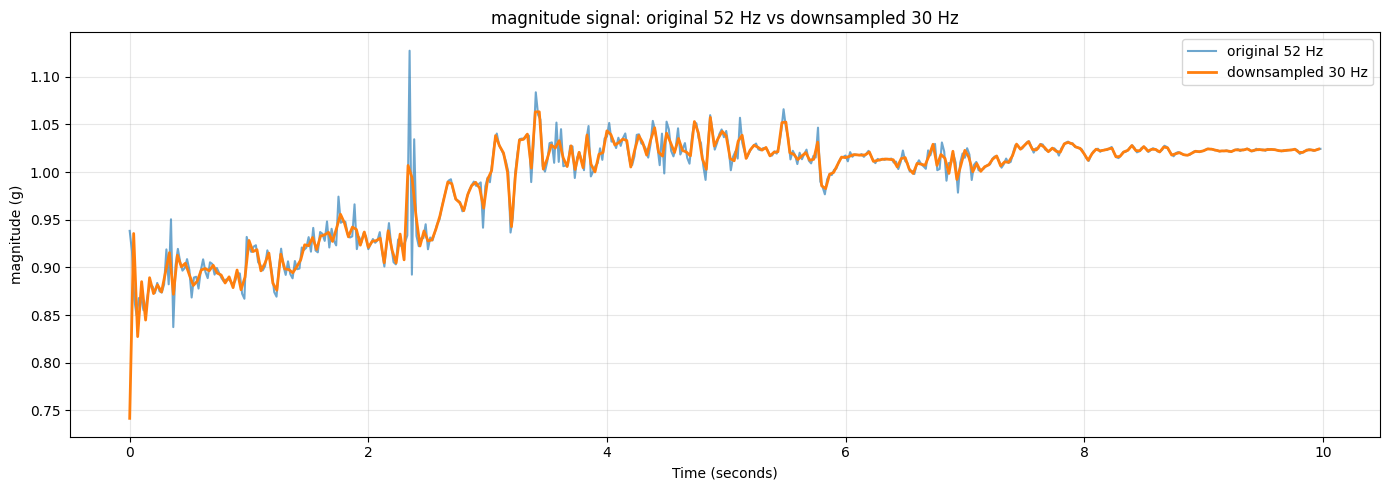

In [13]:
df_g = load_person_converted_to_g(
    person_id=1,
    counts_per_g=counts_per_g,
    base_path="./input"
)

df_30hz = downsample_converted_df(
    df_g,
    old_fs=52,
    new_fs=30
)

plot_original_vs_downsampled(
    df_g,
    df_30hz,
    old_fs=52,
    new_fs=30,
    start_seconds=0,
    window_seconds=10,
    axis="magnitude"
)

In [14]:
def plot_downsampled_with_windows(
    df_down,
    fs=30,
    window_seconds=10,
    start_seconds=0,
    total_seconds=40,
    axis="magnitude"
):
    """
    Plot downsampled signal with 10-second window separators.
    """

    start = int(start_seconds * fs)
    end = start + int(total_seconds * fs)

    df_seg = df_down.iloc[start:end].copy().reset_index(drop=True)

    t = np.arange(len(df_seg)) / fs + start_seconds

    if axis == "x":
        signal = df_seg["x_acceleration"].to_numpy()
        ylabel = "x (g)"
    elif axis == "y":
        signal = df_seg["y_acceleration"].to_numpy()
        ylabel = "y (g)"
    elif axis == "z":
        signal = df_seg["z_acceleration"].to_numpy()
        ylabel = "z (g)"
    elif axis == "magnitude":
        xyz = df_seg[["x_acceleration", "y_acceleration", "z_acceleration"]].to_numpy()
        signal = np.sqrt(np.sum(xyz**2, axis=1))
        ylabel = "magnitude (g)"
    else:
        raise ValueError("axis must be one of: x, y, z, magnitude")

    plt.figure(figsize=(14, 5))
    plt.plot(t, signal, label=f"{axis} signal", linewidth=2)

    # draw window boundaries
    for w_start in np.arange(start_seconds, start_seconds + total_seconds, window_seconds):
        plt.axvline(w_start, linestyle="--", alpha=0.6)

    # optional shading for windows
    for w_start in np.arange(start_seconds, start_seconds + total_seconds, window_seconds):
        plt.axvspan(w_start, w_start + window_seconds, alpha=0.08)

    plt.axhline(1.0, linestyle=":", label="1g reference")

    plt.title(f"Downsampled signal with {window_seconds}s windows ({fs} Hz)")
    plt.xlabel("Time (seconds)")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

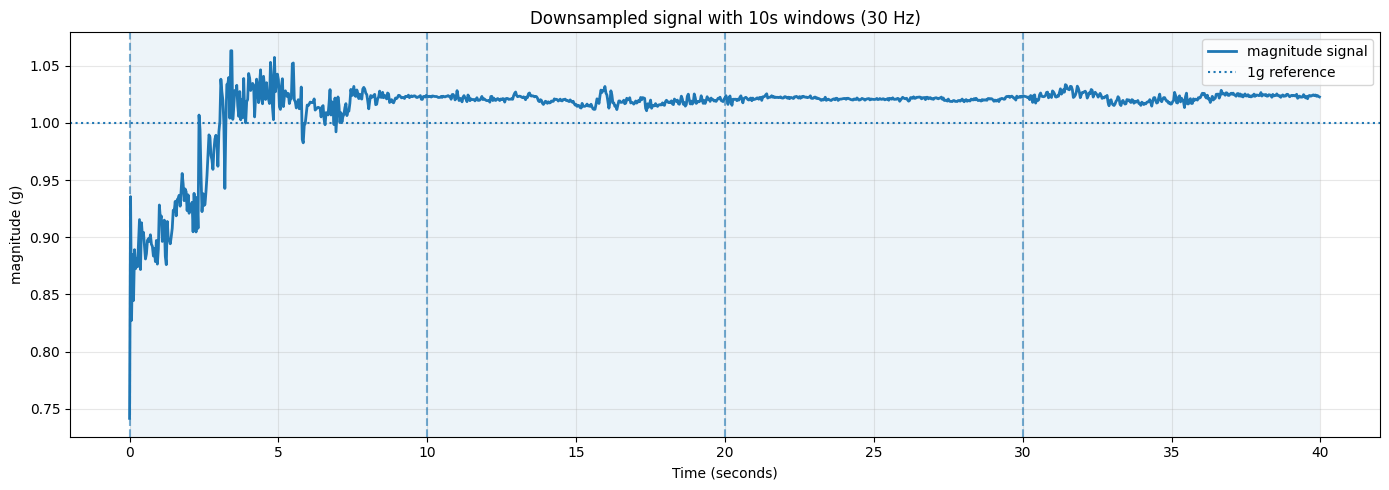

In [15]:
plot_downsampled_with_windows(
    df_down=df_30hz,
    fs=30,
    window_seconds=10,
    start_seconds=0,
    total_seconds=40,
    axis="magnitude"
)

In [16]:
import torch
import numpy as np

repo = "OxWearables/ssl-wearables"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

harnet10 = torch.hub.load(
    repo,
    "harnet10",
    class_num=7,
    pretrained=True
)

harnet10 = harnet10.to(device)
harnet10.eval()

print(harnet10)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/OxWearables/ssl-wearables/zipball/main" to /root/.cache/torch/hub/main.zip
131 Weights loaded
Resnet(
  (feature_extractor): Sequential(
    (layer1): Sequential(
      (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
      (1): ResBlock(
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
        (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False, padding_mode=circular)
        (relu): ReLU(inplace=True)
      )
      (2): ResBlock(
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (c

In [17]:
x_dummy = torch.randn(1, 3, 300).to(device)

with torch.no_grad():
    out = harnet10(x_dummy)

print("Output shape:", out.shape)
print("Output values:", out)

Output shape: torch.Size([1, 7])
Output values: tensor([[-12.6040, -10.7694, -17.0447,   1.1051,  -2.6491,  -2.1153,  -6.9901]],
       device='cuda:0')


In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

def make_10s_windows_from_downsampled_df(
    df_down,
    fs=30,
    window_seconds=10,
    step_seconds=10,
    require_pure_label=True
):
    window_size = int(window_seconds * fs)
    step_size = int(step_seconds * fs)

    xyz = df_down[["x_acceleration", "y_acceleration", "z_acceleration"]].astype(float).to_numpy()
    labels = df_down["Labels"].to_numpy()

    X = []
    y = []

    for start in range(0, len(df_down) - window_size + 1, step_size):
        end = start + window_size

        window_labels = labels[start:end]
        unique_labels, counts = np.unique(window_labels, return_counts=True)

        if require_pure_label and len(unique_labels) != 1:
            continue

        majority_label = unique_labels[np.argmax(counts)]

        # model expects (channels, time) = (3, 300)
        X.append(xyz[start:end].T)
        y.append(majority_label)

    return np.array(X, dtype=np.float32), np.array(y)


def extract_harnet_features(model, X, batch_size=64):
    model.eval()
    device = next(model.parameters()).device

    features = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32).to(device)

            # Try common feature extractor access
            if hasattr(model, "feature_extractor"):
                fb = model.feature_extractor(xb)
            else:
                # fallback: remove final classifier if model is sequential-like
                fb = model[:-1](xb)

            fb = fb.reshape(fb.shape[0], -1)
            features.append(fb.cpu().numpy())

    return np.concatenate(features, axis=0)

def plot_harnet_tsne_with_labels(
    model,
    df_down,
    label_names,
    fs=30,
    window_seconds=10,
    step_seconds=10,
    require_pure_label=True,
    max_windows=1000,
    random_state=42
):
    X, y = make_10s_windows_from_downsampled_df(
        df_down,
        fs=fs,
        window_seconds=window_seconds,
        step_seconds=step_seconds,
        require_pure_label=require_pure_label
    )

    if len(X) > max_windows:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(X), size=max_windows, replace=False)
        X = X[idx]
        y = y[idx]

    features = extract_harnet_features(model, X)

    from sklearn.manifold import TSNE

    tsne = TSNE(
        n_components=2,
        perplexity=min(30, max(5, len(features)//10)),
        learning_rate="auto",
        init="pca",
        random_state=random_state
    )

    Z = tsne.fit_transform(features)

    plt.figure(figsize=(10, 8))

    unique_labels = sorted(np.unique(y))

    for label in unique_labels:
        mask = y == label
        plt.scatter(
            Z[mask, 0],
            Z[mask, 1],
            label=label_names.get(label, f"Label {label}"),
            alpha=0.75
        )

    plt.title("t-SNE of HaRNet feature vectors (with label names)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return Z, y

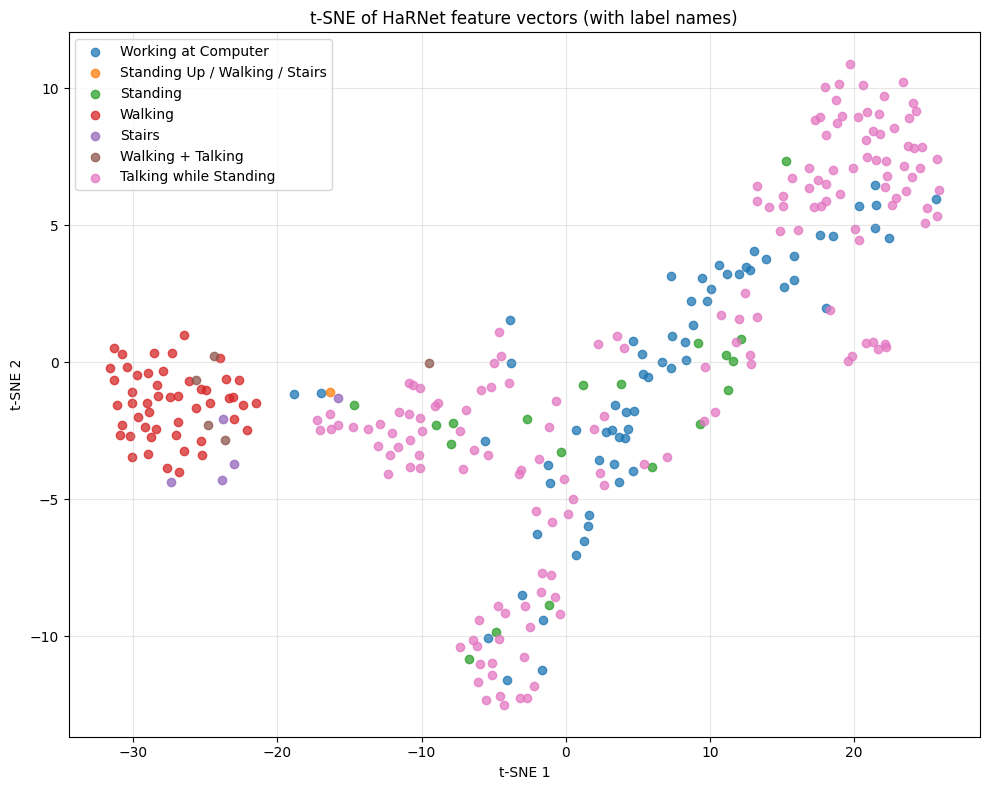

In [19]:
label_names = {
    1: "Working at Computer",
    2: "Standing Up / Walking / Stairs",
    3: "Standing",
    4: "Walking",
    5: "Stairs",
    6: "Walking + Talking",
    7: "Talking while Standing"
}

Z, y = plot_harnet_tsne_with_labels(
    model=harnet10,
    df_down=df_30hz,
    label_names=label_names
)

In [20]:
def build_harnet_window_dataset(
    person_ids=range(1, 16),
    counts_per_g=counts_per_g,
    base_path="./input",
    old_fs=52,
    new_fs=30,
    window_seconds=10,
    step_seconds=5,
    require_pure_label=True
):
    X_all = []
    y_all = []

    for pid in person_ids:
        df_g = load_person_converted_to_g(
            person_id=pid,
            counts_per_g=counts_per_g,
            base_path=base_path
        )

        df_down = downsample_converted_df(
            df_g,
            old_fs=old_fs,
            new_fs=new_fs
        )

        X_pid, y_pid = make_10s_windows_from_downsampled_df(
            df_down,
            fs=new_fs,
            window_seconds=window_seconds,
            step_seconds=step_seconds,
            require_pure_label=require_pure_label
        )

        X_all.append(X_pid)
        y_all.append(y_pid)

    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)

    return X_all, y_all

In [21]:
X, y_raw = build_harnet_window_dataset(
    person_ids=range(1, 16),
    counts_per_g=counts_per_g,
    window_seconds=10,
    step_seconds=5,
    require_pure_label=True
)

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("X:", X.shape)   # should be (num_windows, 3, 300)
print("y:", y.shape)
print("Classes:", label_encoder.classes_)
print("Counts:", dict(zip(*np.unique(y_raw, return_counts=True))))

X: (7140, 3, 300)
y: (7140,)
Classes: [1 2 3 4 5 6 7]
Counts: {np.int64(1): np.int64(2319), np.int64(2): np.int64(154), np.int64(3): np.int64(744), np.int64(4): np.int64(1346), np.int64(5): np.int64(167), np.int64(6): np.int64(154), np.int64(7): np.int64(2256)}


In [22]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "None")
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
Device count: 1
Current device: 0
Device name: Tesla T4


In [23]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=6758,
    stratify=y
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

def extract_features_for_classifier(model, X, batch_size=64):
    model.eval()
    model.to(device)

    feats = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32).to(device)

            if hasattr(model, "feature_extractor"):
                fb = model.feature_extractor(xb)
            else:
                fb = model[:-1](xb)

            fb = fb.reshape(fb.shape[0], -1)
            feats.append(fb.cpu())

    return torch.cat(feats, dim=0)


X_train_feat = extract_features_for_classifier(harnet10, X_train)
X_test_feat = extract_features_for_classifier(harnet10, X_test)

print("Train feature shape:", X_train_feat.shape)
print("Test feature shape:", X_test_feat.shape)

Using: cuda
Train feature shape: torch.Size([4998, 1024])
Test feature shape: torch.Size([2142, 1024])


In [24]:
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_feat, y_train_t)
test_ds = TensorDataset(X_test_feat, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [25]:
class ClassificationHead(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


head = ClassificationHead(
    input_dim=X_train_feat.shape[1],
    num_classes=len(np.unique(y))
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(head.parameters(), lr=1e-3)

In [26]:
num_epochs = 100
patience = 12

best_val_acc = 0
best_state = None
epochs_without_improve = 0

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    head.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    head.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)

            logits = head(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(pred)
            trues.extend(yb.numpy())

    val_acc = metrics.accuracy_score(trues, preds)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch + 1:03d} | loss={avg_train_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = head.state_dict()
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epochs_without_improve >= patience:
        print("Early stopping.")
        break

head.load_state_dict(best_state)
print("Best validation accuracy:", best_val_acc)

Epoch 001 | loss=1.1451 | val_acc=0.6331
Epoch 002 | loss=1.0309 | val_acc=0.6349
Epoch 003 | loss=1.0072 | val_acc=0.6419
Epoch 004 | loss=0.9865 | val_acc=0.6452
Epoch 005 | loss=0.9636 | val_acc=0.6508
Epoch 006 | loss=0.9481 | val_acc=0.6592
Epoch 007 | loss=0.9326 | val_acc=0.6541
Epoch 008 | loss=0.9236 | val_acc=0.6583
Epoch 009 | loss=0.9022 | val_acc=0.6597
Epoch 010 | loss=0.8762 | val_acc=0.6709
Epoch 011 | loss=0.8751 | val_acc=0.6690
Epoch 012 | loss=0.8780 | val_acc=0.6755
Epoch 013 | loss=0.8592 | val_acc=0.6737
Epoch 014 | loss=0.8369 | val_acc=0.6830
Epoch 015 | loss=0.8324 | val_acc=0.6881
Epoch 016 | loss=0.8175 | val_acc=0.6858
Epoch 017 | loss=0.8202 | val_acc=0.6849
Epoch 018 | loss=0.8131 | val_acc=0.6755
Epoch 019 | loss=0.8011 | val_acc=0.6811
Epoch 020 | loss=0.7957 | val_acc=0.6732
Epoch 021 | loss=0.7911 | val_acc=0.6825
Epoch 022 | loss=0.7884 | val_acc=0.6853
Epoch 023 | loss=0.7687 | val_acc=0.6774
Epoch 024 | loss=0.7722 | val_acc=0.6858
Epoch 025 | loss

Final accuracy: 0.7007469654528478

              precision    recall  f1-score   support

           0       0.62      0.88      0.73       696
           1       0.33      0.15      0.21        46
           2       0.60      0.22      0.32       223
           3       0.92      0.89      0.91       404
           4       0.86      0.36      0.51        50
           5       0.57      0.35      0.43        46
           6       0.71      0.64      0.67       677

    accuracy                           0.70      2142
   macro avg       0.66      0.50      0.54      2142
weighted avg       0.70      0.70      0.68      2142



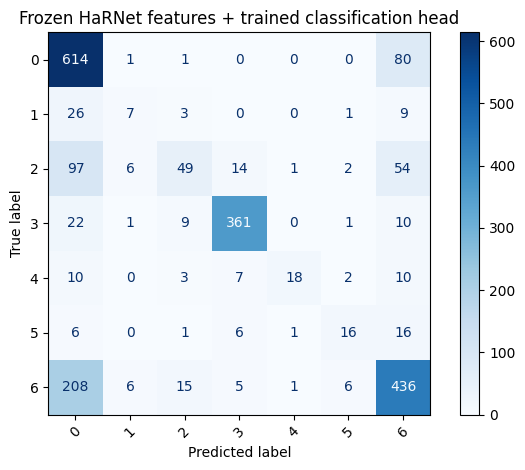

In [27]:
head.eval()

final_preds = []
final_trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = head(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()

        final_preds.extend(pred)
        final_trues.extend(yb.numpy())

print("Final accuracy:", metrics.accuracy_score(final_trues, final_preds))
print()
print(metrics.classification_report(final_trues, final_preds))

ConfusionMatrixDisplay.from_predictions(
    final_trues,
    final_preds,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Frozen HaRNet features + trained classification head")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(val_accuracies, label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [29]:
# Original labels:
# 1 = Working at Computer
# 2 = Standing Up / Walking / Stairs
# 3 = Standing
# 4 = Walking
# 5 = Stairs
# 6 = Walking + Talking
# 7 = Talking while Standing

def collapse_to_binary_labels(y_raw):
    y_binary = []

    for label in y_raw:
        if label in [1, 3, 7]:
            y_binary.append(0)  # static / low-motion
        elif label in [2, 4, 5, 6]:
            y_binary.append(1)  # dynamic / moving
        else:
            raise ValueError(f"Unexpected label: {label}")

    return np.array(y_binary, dtype=int)


y_binary = collapse_to_binary_labels(y_raw)

binary_label_names = {
    0: "Static / Low-motion",
    1: "Dynamic / Moving"
}

print("Binary label counts:", dict(zip(*np.unique(y_binary, return_counts=True))))

Binary label counts: {np.int64(0): np.int64(5319), np.int64(1): np.int64(1821)}


In [30]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.3,
    random_state=6758,
    stratify=y_binary
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [31]:
def extract_features_for_classifier(model, X, batch_size=64):
    model.eval()
    model.to(device)

    feats = []

    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32).to(device)

            if hasattr(model, "feature_extractor"):
                fb = model.feature_extractor(xb)
            else:
                fb = model[:-1](xb)

            fb = fb.reshape(fb.shape[0], -1)
            feats.append(fb.cpu())

    return torch.cat(feats, dim=0)


X_train_feat = extract_features_for_classifier(harnet10, X_train)
X_test_feat = extract_features_for_classifier(harnet10, X_test)

print("Train features:", X_train_feat.shape)
print("Test features:", X_test_feat.shape)

Train features: torch.Size([4998, 1024])
Test features: torch.Size([2142, 1024])


In [32]:
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_feat, y_train_t)
test_ds = TensorDataset(X_test_feat, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [33]:
class BinaryClassificationHead(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)


binary_head = BinaryClassificationHead(
    input_dim=X_train_feat.shape[1]
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(binary_head.parameters(), lr=1e-3)

In [34]:
num_epochs = 100
patience = 12

best_val_acc = 0
best_state = None
epochs_without_improve = 0

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    binary_head.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = binary_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    binary_head.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = binary_head(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(pred)
            trues.extend(yb.numpy())

    val_acc = metrics.accuracy_score(trues, preds)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch + 1:03d} | loss={avg_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = binary_head.state_dict()
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epochs_without_improve >= patience:
        print("Early stopping.")
        break

binary_head.load_state_dict(best_state)
print("Best validation accuracy:", best_val_acc)

Epoch 001 | loss=0.3251 | val_acc=0.9108
Epoch 002 | loss=0.2851 | val_acc=0.9132
Epoch 003 | loss=0.2773 | val_acc=0.9160
Epoch 004 | loss=0.2725 | val_acc=0.9160
Epoch 005 | loss=0.2655 | val_acc=0.9150
Epoch 006 | loss=0.2618 | val_acc=0.9164
Epoch 007 | loss=0.2610 | val_acc=0.9211
Epoch 008 | loss=0.2584 | val_acc=0.9206
Epoch 009 | loss=0.2497 | val_acc=0.9183
Epoch 010 | loss=0.2508 | val_acc=0.9183
Epoch 011 | loss=0.2433 | val_acc=0.9211
Epoch 012 | loss=0.2424 | val_acc=0.9230
Epoch 013 | loss=0.2323 | val_acc=0.9225
Epoch 014 | loss=0.2365 | val_acc=0.9234
Epoch 015 | loss=0.2268 | val_acc=0.9202
Epoch 016 | loss=0.2254 | val_acc=0.9267
Epoch 017 | loss=0.2280 | val_acc=0.9206
Epoch 018 | loss=0.2273 | val_acc=0.9239
Epoch 019 | loss=0.2211 | val_acc=0.9188
Epoch 020 | loss=0.2253 | val_acc=0.9248
Epoch 021 | loss=0.2107 | val_acc=0.9216
Epoch 022 | loss=0.2102 | val_acc=0.9234
Epoch 023 | loss=0.2192 | val_acc=0.9234
Epoch 024 | loss=0.2108 | val_acc=0.9225
Epoch 025 | loss

Binary accuracy: 0.9234360410831

                     precision    recall  f1-score   support

Static / Low-motion       0.93      0.97      0.95      1596
   Dynamic / Moving       0.89      0.80      0.84       546

           accuracy                           0.92      2142
          macro avg       0.91      0.88      0.90      2142
       weighted avg       0.92      0.92      0.92      2142



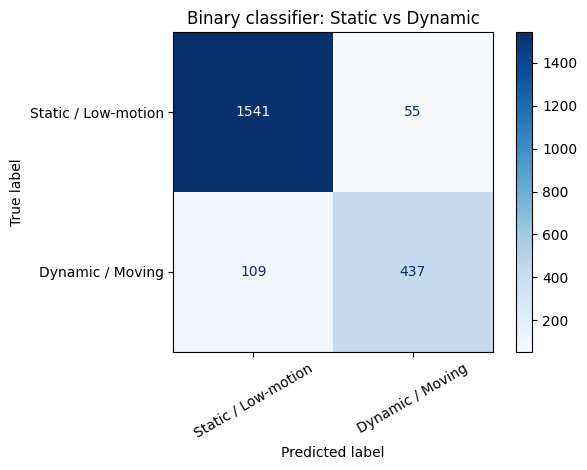

In [35]:
binary_head.eval()

final_preds = []
final_trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = binary_head(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()

        final_preds.extend(pred)
        final_trues.extend(yb.numpy())

print("Binary accuracy:", metrics.accuracy_score(final_trues, final_preds))
print()
print(metrics.classification_report(
    final_trues,
    final_preds,
    target_names=[
        binary_label_names[0],
        binary_label_names[1]
    ]
))

ConfusionMatrixDisplay.from_predictions(
    final_trues,
    final_preds,
    display_labels=[
        binary_label_names[0],
        binary_label_names[1]
    ],
    cmap="Blues",
    xticks_rotation=30
)

plt.title("Binary classifier: Static vs Dynamic")
plt.tight_layout()
plt.show()

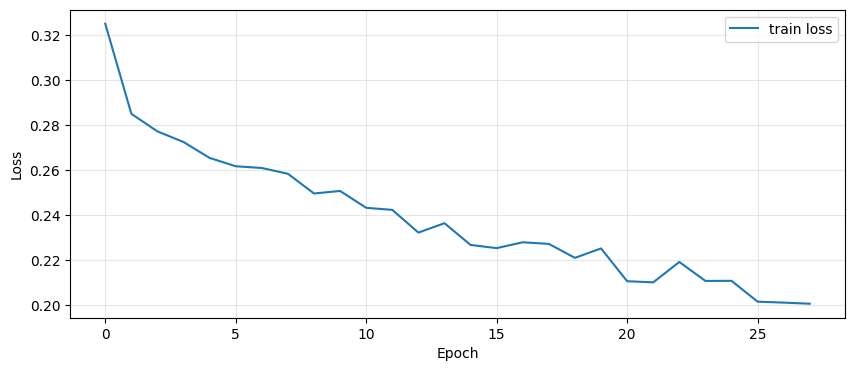

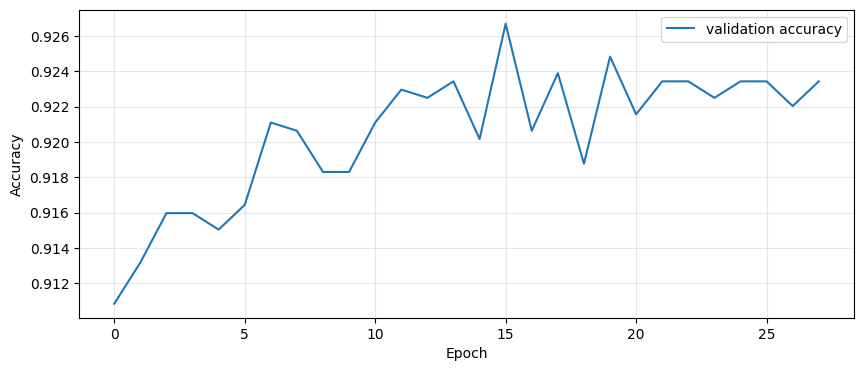

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(val_accuracies, label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()